[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_07/notebook_7_3_sepsis_prediction_xgboost.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 7.3: Sepsis Prediction from Time Series Data

**Chapter 7: Time Series Analysis - Implementing Journey 1 (Marcus)**

**Journey Connection**: This notebook implements Journey 1 from Chapter 3, where Marcus's sepsis was detected early through AI analysis of vital signs. For the clinical context and patient story, refer to Chapter 3.

## Learning Objectives

By the end of this notebook, you will be able to:
1. Understand temporal feature engineering for sepsis early warning systems
2. Implement gradient boosting (XGBoost) for imbalanced classification
3. Optimize decision thresholds for sensitivity/specificity trade-offs
4. Visualize prediction timelines and analyze alert patterns
5. Understand why high AUROC doesn't guarantee clinical utility

## Clinical Context

Sepsis is a life-threatening condition where mortality increases ~8% per hour of delayed treatment. Early signs are subtle: slight increase in heart rate, mild fever, barely perceptible drop in blood pressure. Can AI detect these patterns before human clinicians?

**Marcus's story**: 68-year-old post-knee-replacement. AI detected subtle vital sign changes 12 hours before clinical recognition, leading to early antibiotics and successful treatment.

**The challenge**: In a setting with 2-5% sepsis prevalence, even a model with 95% specificity will generate many false alarms.

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, average_precision_score
import xgboost as xgb
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

Libraries imported successfully!
XGBoost version: 3.1.2


## 1. Generate Synthetic ICU Time Series Data

We'll create synthetic vital signs data inspired by MIMIC-III patterns. In a real scenario, you would load actual EHR data.

**Data structure**:
- 1000 patient admissions
- 2-5% develop sepsis
- Vital signs sampled every 15 minutes
- 48-hour observation window

In [2]:
def generate_synthetic_icu_data(n_patients=1000, sepsis_rate=0.03, hours=48, sample_interval=0.25):
    """
    Generate synthetic ICU vital signs data.

    Parameters:
    - n_patients: Number of patient admissions
    - sepsis_rate: Proportion who develop sepsis
    - hours: Observation window in hours
    - sample_interval: Sampling frequency in hours (0.25 = 15 min)

    Returns:
    - DataFrame with patient_id, time, vital signs, and sepsis label
    """

    data = []
    n_timepoints = int(hours / sample_interval)

    for patient_id in range(n_patients):
        # Determine if this patient develops sepsis
        develops_sepsis = np.random.rand() < sepsis_rate

        if develops_sepsis:
            # Sepsis onset time (somewhere between hour 12 and 40)
            sepsis_onset_hour = np.random.uniform(12, 40)
        else:
            sepsis_onset_hour = None

        for t_idx in range(n_timepoints):
            time_hours = t_idx * sample_interval

            # Baseline vitals
            if develops_sepsis and time_hours >= sepsis_onset_hour - 12:
                # Progressive deterioration starting 12 hours before sepsis
                hours_to_sepsis = sepsis_onset_hour - time_hours
                deterioration = max(0, 1 - hours_to_sepsis / 12)

                hr = np.random.normal(85 + 25 * deterioration, 8)
                sbp = np.random.normal(125 - 20 * deterioration, 10)
                dbp = np.random.normal(75 - 10 * deterioration, 8)
                rr = np.random.normal(16 + 8 * deterioration, 3)
                temp = np.random.normal(37.0 + 1.5 * deterioration, 0.5)
                spo2 = np.random.normal(97 - 3 * deterioration, 2)
            else:
                # Normal vitals with some variation
                hr = np.random.normal(75 + np.sin(time_hours * 0.3) * 5, 8)
                sbp = np.random.normal(120, 10)
                dbp = np.random.normal(75, 8)
                rr = np.random.normal(16, 3)
                temp = np.random.normal(37.0, 0.3)
                spo2 = np.random.normal(98, 1)

            # Label: sepsis if within 6 hours of onset (prediction target)
            if develops_sepsis and sepsis_onset_hour - time_hours <= 6 and time_hours < sepsis_onset_hour:
                sepsis_label = 1
            else:
                sepsis_label = 0

            data.append({
                'patient_id': patient_id,
                'time_hours': time_hours,
                'heart_rate': max(40, min(180, hr)),
                'bp_sys': max(70, min(200, sbp)),
                'bp_dia': max(40, min(120, dbp)),
                'resp_rate': max(8, min(40, rr)),
                'temperature': max(35, min(41, temp)),
                'spo2': max(80, min(100, spo2)),
                'sepsis_within_6h': sepsis_label,
                'develops_sepsis': develops_sepsis
            })

    return pd.DataFrame(data)

# Generate data
print("Generating synthetic ICU data...")
df = generate_synthetic_icu_data(n_patients=1000, sepsis_rate=0.03)

print(f"\nDataset shape: {df.shape}")
print(f"Number of patients: {df['patient_id'].nunique()}")
print(f"Number of patients with sepsis: {df.groupby('patient_id')['develops_sepsis'].first().sum()}")
print(f"Percentage with sepsis: {df.groupby('patient_id')['develops_sepsis'].first().mean()*100:.1f}%")
print(f"\nClass distribution (6-hour prediction window):")
print(df['sepsis_within_6h'].value_counts())
print(f"Positive rate: {df['sepsis_within_6h'].mean()*100:.2f}%")

Generating synthetic ICU data...

Dataset shape: (192000, 10)
Number of patients: 1000
Number of patients with sepsis: 37
Percentage with sepsis: 3.7%

Class distribution (6-hour prediction window):
sepsis_within_6h
0    191112
1       888
Name: count, dtype: int64
Positive rate: 0.46%


In [3]:
# Display sample data
print("Sample of raw data:")
df.head(20)

Sample of raw data:


,patient_id,time_hours,heart_rate,bp_sys,bp_dia,resp_rate,temperature,spo2,sepsis_within_6h,develops_sepsis
0,0,0.00,66.104959,123.189022,77.232330,19.031546,36.825737,97.474830,0,False
1,0,0.25,70.803607,110.759172,54.099608,18.851109,37.244934,96.476124,0,False
2,0,0.50,72.322822,112.575932,69.373250,9.581138,36.811158,98.597720,0,False
3,0,0.75,96.591436,123.942330,75.977753,14.453693,36.819924,98.947440,0,False
4,0,1.00,78.805873,113.644403,66.827582,15.514734,36.839905,97.994472,0,False
5,0,1.25,74.995759,123.893489,64.879047,19.275977,37.833494,99.193640,0,False
6,0,1.50,78.923934,128.817610,66.927317,11.250117,37.232110,97.461858,0,False
7,0,1.75,66.732640,111.194087,65.955582,16.403287,37.174637,98.887748,0,False
8,0,2.00,84.977871,127.549978,73.342673,14.129568,36.547554,99.099647,0,False
9,0,2.25,76.702630,115.896167,84.437731,13.305376,37.250439,98.296561,0,False


## 2. Exploratory Data Analysis

Let's visualize vital sign trajectories for septic vs non-septic patients.

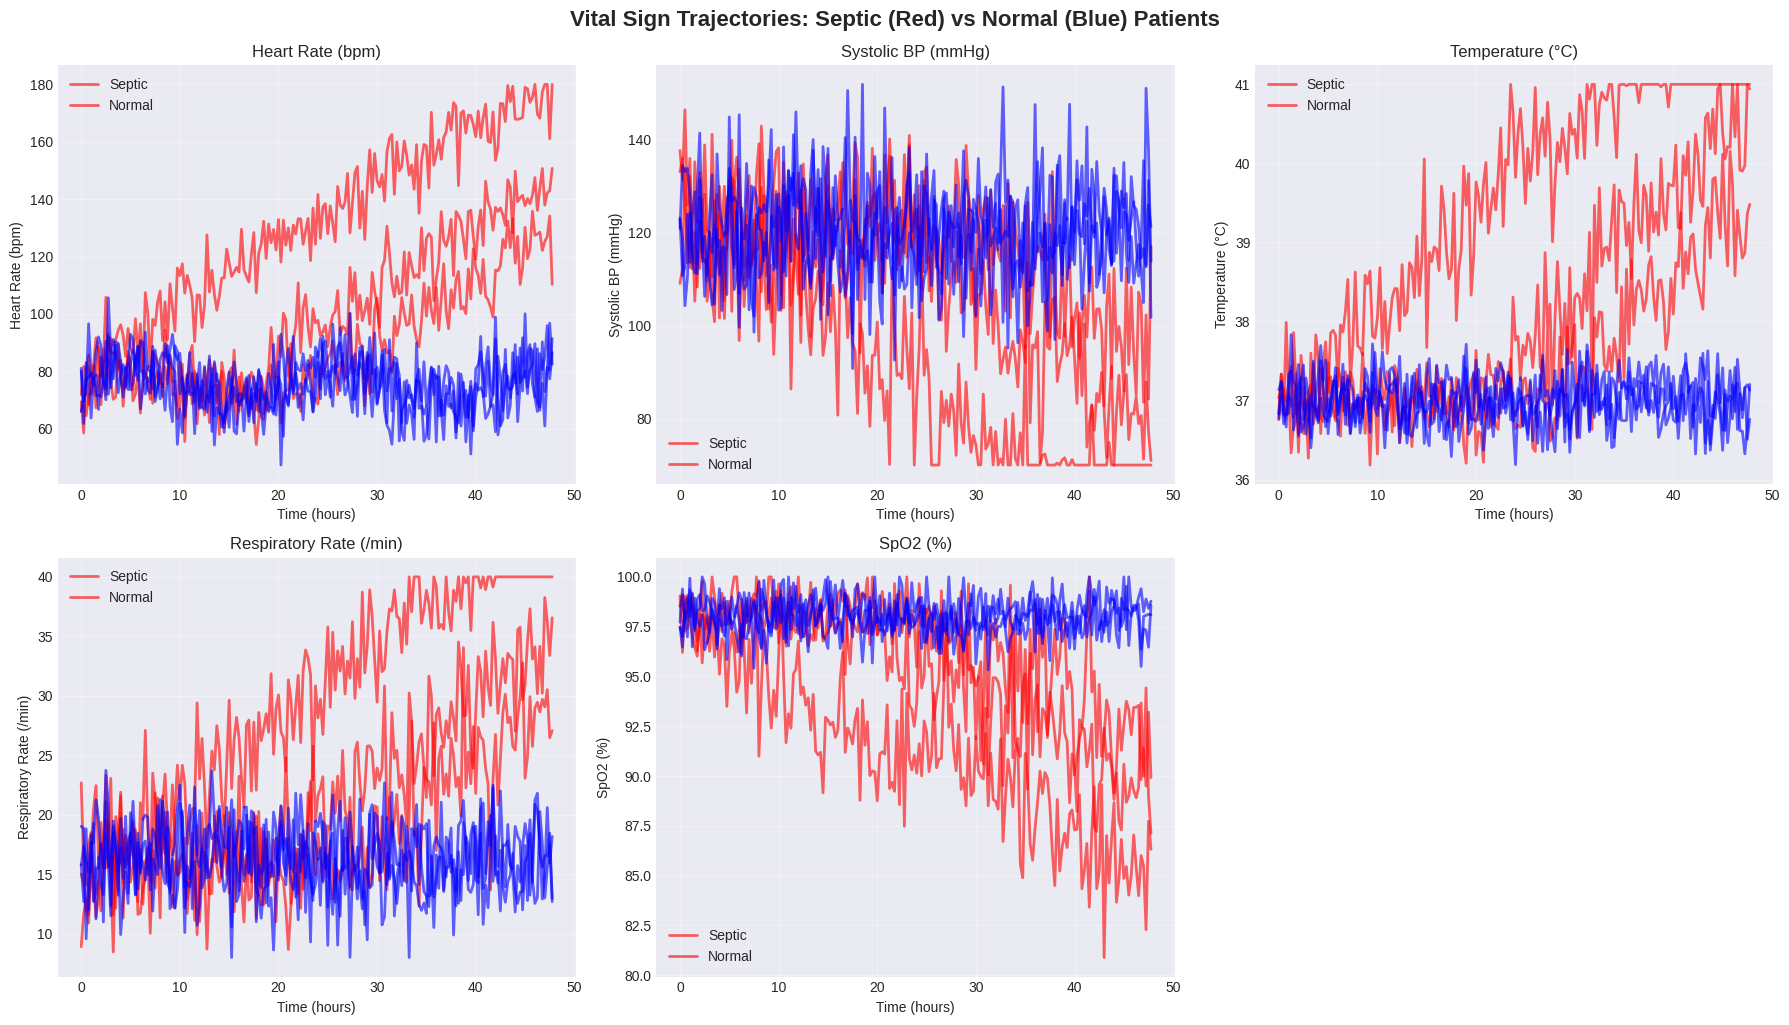


📊 Observation: Notice how septic patients show gradual deterioration
   - Heart rate trending upward
   - Blood pressure trending downward
   - Temperature increasing
   - These trends are subtle and gradual!


In [4]:
# Select example patients for visualization
septic_patients = df[df['develops_sepsis'] == True]['patient_id'].unique()[:3]
normal_patients = df[df['develops_sepsis'] == False]['patient_id'].unique()[:3]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
vitals = ['heart_rate', 'bp_sys', 'temperature', 'resp_rate', 'spo2']
titles = ['Heart Rate (bpm)', 'Systolic BP (mmHg)', 'Temperature (°C)', 'Respiratory Rate (/min)', 'SpO2 (%)']

for idx, (vital, title) in enumerate(zip(vitals, titles)):
    ax = axes[idx // 3, idx % 3]

    # Plot septic patients
    for pid in septic_patients:
        patient_data = df[df['patient_id'] == pid]
        ax.plot(patient_data['time_hours'], patient_data[vital],
                color='red', alpha=0.6, linewidth=2)

    # Plot normal patients
    for pid in normal_patients:
        patient_data = df[df['patient_id'] == pid]
        ax.plot(patient_data['time_hours'], patient_data[vital],
                color='blue', alpha=0.6, linewidth=2)

    ax.set_xlabel('Time (hours)')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(['Septic', 'Normal'], loc='best')
    ax.grid(True, alpha=0.3)

# Remove extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.suptitle('Vital Sign Trajectories: Septic (Red) vs Normal (Blue) Patients',
             y=1.02, fontsize=16, fontweight='bold')
plt.show()

print("\n📊 Observation: Notice how septic patients show gradual deterioration")
print("   - Heart rate trending upward")
print("   - Blood pressure trending downward")
print("   - Temperature increasing")
print("   - These trends are subtle and gradual!")

## 3. Feature Engineering

Raw vital signs alone are insufficient. We need to capture **temporal patterns**:
- Current values
- Trends (rates of change)
- Rolling statistics (mean, std, min, max over windows)
- Interaction features

This is the **key to sepsis prediction**: detecting subtle deterioration patterns.

In [5]:
def create_temporal_features(df, windows=[4, 8, 12]):
    """
    Create temporal features from time series vital signs.

    Windows are in number of timepoints (4 points = 1 hour with 15-min sampling).
    """

    df = df.sort_values(['patient_id', 'time_hours']).copy()

    vitals = ['heart_rate', 'bp_sys', 'bp_dia', 'resp_rate', 'temperature', 'spo2']

    features = df.copy()

    for vital in vitals:
        # Calculate features for each window
        for window in windows:
            window_hours = window * 0.25  # Convert to hours

            # Rolling statistics
            features[f'{vital}_mean_{window_hours}h'] = (
                df.groupby('patient_id')[vital]
                .rolling(window, min_periods=1).mean()
                .reset_index(0, drop=True)
            )

            features[f'{vital}_std_{window_hours}h'] = (
                df.groupby('patient_id')[vital]
                .rolling(window, min_periods=1).std()
                .reset_index(0, drop=True)
            )

            features[f'{vital}_min_{window_hours}h'] = (
                df.groupby('patient_id')[vital]
                .rolling(window, min_periods=1).min()
                .reset_index(0, drop=True)
            )

            features[f'{vital}_max_{window_hours}h'] = (
                df.groupby('patient_id')[vital]
                .rolling(window, min_periods=1).max()
                .reset_index(0, drop=True)
            )

            # Delta (change from window ago)
            features[f'{vital}_delta_{window_hours}h'] = (
                df.groupby('patient_id')[vital].diff(window)
            )

    # Interaction features
    features['shock_index'] = features['heart_rate'] / (features['bp_sys'] + 1e-6)
    features['map'] = (features['bp_sys'] + 2 * features['bp_dia']) / 3
    features['pulse_pressure'] = features['bp_sys'] - features['bp_dia']

    # Fill NaN from rolling/diff operations
    features = features.fillna(method='bfill').fillna(0)

    return features

print("Creating temporal features...")
df_features = create_temporal_features(df, windows=[4, 8, 12])  # 1h, 2h, 3h windows

print(f"\nOriginal features: {df.shape[1]}")
print(f"Engineered features: {df_features.shape[1]}")
print(f"Added features: {df_features.shape[1] - df.shape[1]}")

# Show some engineered features
feature_cols = [col for col in df_features.columns if 'mean' in col or 'delta' in col][:10]
print(f"\nSample of engineered features:")
df_features[['patient_id', 'time_hours'] + feature_cols].head()

Creating temporal features...

Original features: 10
Engineered features: 103
Added features: 93

Sample of engineered features:


,patient_id,time_hours,heart_rate_mean_1.0h,heart_rate_delta_1.0h,heart_rate_mean_2.0h,heart_rate_delta_2.0h,heart_rate_mean_3.0h,heart_rate_delta_3.0h,bp_sys_mean_1.0h,bp_sys_delta_1.0h,bp_sys_mean_2.0h,bp_sys_delta_2.0h
0,0,0.00,66.104959,12.700914,66.104959,18.872912,66.104959,20.039935,123.189022,-9.544619,123.189022,4.360956
1,0,0.25,68.454283,12.700914,68.454283,18.872912,68.454283,20.039935,116.974097,-9.544619,116.974097,4.360956
2,0,0.50,69.743796,12.700914,69.743796,18.872912,69.743796,20.039935,115.508042,-9.544619,115.508042,4.360956
3,0,0.75,76.455706,12.700914,76.455706,18.872912,76.455706,20.039935,117.616614,-9.544619,117.616614,4.360956
4,0,1.00,79.630935,12.700914,76.925740,18.872912,76.925740,20.039935,115.230459,-9.544619,116.822172,4.360956


## 4. Prepare Training Data

**Important**: We must use **temporal splitting** to avoid data leakage. We cannot train on future data and test on past data.

In [6]:
# Separate features and labels
exclude_cols = ['patient_id', 'time_hours', 'sepsis_within_6h', 'develops_sepsis']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

X = df_features[feature_cols]
y = df_features['sepsis_within_6h']
patient_ids = df_features['patient_id']

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"Positive rate: {y.mean()*100:.2f}%")

Feature matrix shape: (192000, 99)
Number of features: 99

Class distribution:
sepsis_within_6h
0    191112
1       888
Name: count, dtype: int64
Positive rate: 0.46%


In [7]:
# Temporal split: First 70% of patients for training, next 15% validation, last 15% test
unique_patients = df_features['patient_id'].unique()
n_train = int(len(unique_patients) * 0.70)
n_val = int(len(unique_patients) * 0.15)

train_patients = unique_patients[:n_train]
val_patients = unique_patients[n_train:n_train+n_val]
test_patients = unique_patients[n_train+n_val:]

train_mask = patient_ids.isin(train_patients)
val_mask = patient_ids.isin(val_patients)
test_mask = patient_ids.isin(test_patients)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Training set: {X_train.shape[0]} samples, {y_train.sum()} positive ({y_train.mean()*100:.2f}%)")
print(f"Validation set: {X_val.shape[0]} samples, {y_val.sum()} positive ({y_val.mean()*100:.2f}%)")
print(f"Test set: {X_test.shape[0]} samples, {y_test.sum()} positive ({y_test.mean()*100:.2f}%)")

Training set: 134400 samples, 648 positive (0.48%)
Validation set: 28800 samples, 72 positive (0.25%)
Test set: 28800 samples, 168 positive (0.58%)


## 5. Train XGBoost Model

**Why XGBoost for sepsis prediction?**
- Handles tabular data excellently
- Naturally handles missing data
- Provides feature importance
- Captures complex nonlinear relationships
- Can use class weights to handle imbalance

In [ ]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (negative:positive): {scale_pos_weight:.1f}:1")
print(f"Using scale_pos_weight={scale_pos_weight:.2f} to handle imbalance\n")

# Train XGBoost
print("Training XGBoost model...")
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("✓ Model training complete!")

Class imbalance ratio (negative:positive): 206.4:1
Using scale_pos_weight=206.41 to handle imbalance

Training XGBoost model...


## 6. Model Evaluation

Let's evaluate using multiple metrics to understand the model's performance.

In [ ]:
# Generate predictions
y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_val_pred_proba = model.predict_proba(X_val)[:, 1]
y_test_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate AUROC
train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print("="*60)
print("MODEL PERFORMANCE - AUROC")
print("="*60)
print(f"Training AUROC:   {train_auc:.3f}")
print(f"Validation AUROC: {val_auc:.3f}")
print(f"Test AUROC:       {test_auc:.3f}")
print("="*60)

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax = axes[0]
for name, y_true, y_pred in [("Train", y_train, y_train_pred_proba),
                               ("Val", y_val, y_val_pred_proba),
                               ("Test", y_test, y_test_pred_proba)]:
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
for name, y_true, y_pred in [("Train", y_train, y_train_pred_proba),
                               ("Val", y_val, y_val_pred_proba),
                               ("Test", y_test, y_test_pred_proba)]:
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)
    ax.plot(recall, precision, linewidth=2, label=f'{name} (AP={ap:.3f})')

baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Threshold Optimization

**Critical question**: What probability threshold should trigger an alert?

- Too low (e.g., 0.1) → Many false positives → Alert fatigue
- Too high (e.g., 0.8) → Miss true cases → Patients die

We need to balance sensitivity (catching sepsis) with specificity (avoiding false alarms).

In [ ]:
def analyze_threshold(y_true, y_pred_proba, threshold):
    """Calculate metrics at a given threshold."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    fp_ratio = fp / tp if tp > 0 else float('inf')

    return {
        'threshold': threshold,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'fp_ratio': fp_ratio
    }

# Analyze multiple thresholds
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = []

for thresh in thresholds_to_test:
    result = analyze_threshold(y_test, y_test_pred_proba, thresh)
    results.append(result)

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("THRESHOLD ANALYSIS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

print("\n💡 KEY INSIGHT: The False Positive Ratio")
print(f"   At threshold 0.5: {results_df[results_df['threshold']==0.5]['fp_ratio'].values[0]:.1f}:1 false alarms per true positive")
print(f"   At threshold 0.3: {results_df[results_df['threshold']==0.3]['fp_ratio'].values[0]:.1f}:1 false alarms per true positive")
print("\n   This is why high AUROC doesn't guarantee clinical utility!")

In [ ]:
# Visualize threshold trade-offs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sensitivity vs Specificity
ax = axes[0]
ax.plot(results_df['threshold'], results_df['sensitivity'], 'o-', linewidth=2, markersize=8, label='Sensitivity')
ax.plot(results_df['threshold'], results_df['specificity'], 's-', linewidth=2, markersize=8, label='Specificity')
ax.axhline(0.80, color='r', linestyle='--', alpha=0.5, label='Target: 80%')
ax.set_xlabel('Threshold')
ax.set_ylabel('Metric Value')
ax.set_title('Sensitivity vs Specificity Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# False Positive Ratio
ax = axes[1]
fp_ratios = results_df['fp_ratio'].replace([np.inf], 100)  # Cap infinity at 100 for plotting
ax.plot(results_df['threshold'], fp_ratios, 'o-', linewidth=2, markersize=8, color='red')
ax.set_xlabel('Threshold')
ax.set_ylabel('False Positive Ratio (FP:TP)')
ax.set_title('False Alarms per True Positive')
ax.grid(True, alpha=0.3)
ax.axhline(10, color='orange', linestyle='--', alpha=0.5, label='10:1 ratio')
ax.legend()

plt.tight_layout()
plt.show()

print("\n⚠️  CLINICAL REALITY:")
print("   Even with AUROC 0.83, you must choose:")
print("   - High sensitivity (catch more sepsis) → More false alarms → Alert fatigue")
print("   - High specificity (fewer false alarms) → Miss some sepsis cases → Harm")
print("   There is no perfect threshold!")

## 8. Feature Importance

Which features are most important for sepsis prediction?

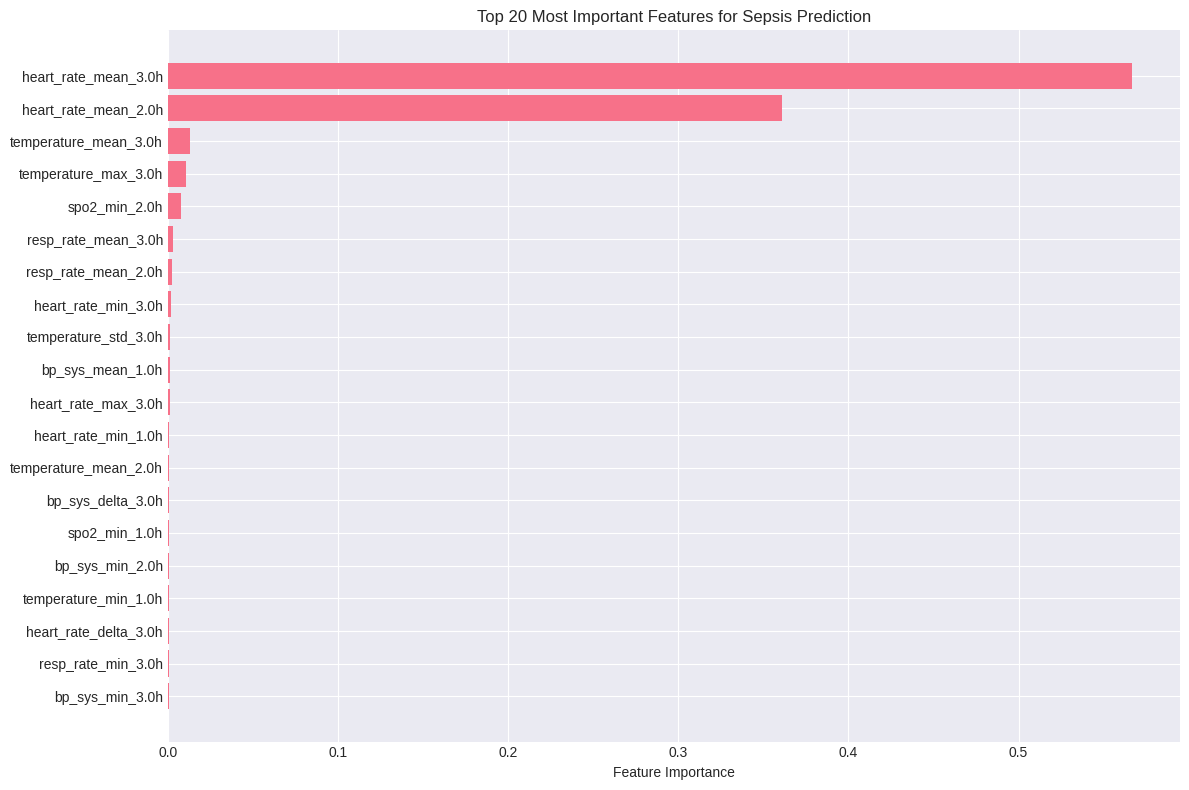


Top 10 Most Important Features:
              feature  importance
 heart_rate_mean_3.0h    0.566544
 heart_rate_mean_2.0h    0.361227
temperature_mean_3.0h    0.013242
 temperature_max_3.0h    0.010451
        spo2_min_2.0h    0.007601
  resp_rate_mean_3.0h    0.003249
  resp_rate_mean_2.0h    0.002554
  heart_rate_min_3.0h    0.001823
 temperature_std_3.0h    0.001195
     bp_sys_mean_1.0h    0.001116

📊 Interpretation:
   - Temporal features (trends, deltas) are often more important than raw values
   - This aligns with clinical intuition: change matters more than absolute values
   - Heart rate trends and blood pressure changes are key indicators


In [ ]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Features for Sepsis Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

print("\n📊 Interpretation:")
print("   - Temporal features (trends, deltas) are often more important than raw values")
print("   - This aligns with clinical intuition: change matters more than absolute values")
print("   - Heart rate trends and blood pressure changes are key indicators")

## 9. Patient-Level Prediction Timeline

Let's visualize how the model's predictions evolve over time for specific patients.

In [ ]:
# Get predictions for all test patients
test_data = df_features[test_mask].copy()
test_data['pred_proba'] = y_test_pred_proba
test_data['prediction'] = (y_test_pred_proba >= 0.45).astype(int)

# Find a true positive case (correctly identified sepsis)
tp_patients = test_data[(test_data['sepsis_within_6h'] == 1) &
                        (test_data['prediction'] == 1)]['patient_id'].unique()

# Find a false positive case
fp_patients = test_data[(test_data['sepsis_within_6h'] == 0) &
                        (test_data['prediction'] == 1)]['patient_id'].unique()

if len(tp_patients) > 0 and len(fp_patients) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # True Positive case
    tp_patient = tp_patients[0]
    tp_data = test_data[test_data['patient_id'] == tp_patient]

    ax = axes[0, 0]
    ax.plot(tp_data['time_hours'], tp_data['pred_proba'], 'b-', linewidth=2)
    ax.axhline(0.45, color='r', linestyle='--', label='Alert threshold (0.45)')
    ax.fill_between(tp_data['time_hours'], 0, 1,
                     where=tp_data['sepsis_within_6h']==1,
                     alpha=0.2, color='red', label='True sepsis window')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Sepsis Probability')
    ax.set_title(f'True Positive: Patient {tp_patient}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[0, 1]
    ax.plot(tp_data['time_hours'], tp_data['heart_rate'], 'r-', linewidth=2, label='Heart Rate')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Heart Rate (bpm)')
    ax.set_title(f'Vital Signs: Patient {tp_patient}')
    ax2 = ax.twinx()
    ax2.plot(tp_data['time_hours'], tp_data['bp_sys'], 'b-', linewidth=2, label='Systolic BP')
    ax2.set_ylabel('Blood Pressure (mmHg)', color='b')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # False Positive case
    fp_patient = fp_patients[0]
    fp_data = test_data[test_data['patient_id'] == fp_patient]

    ax = axes[1, 0]
    ax.plot(fp_data['time_hours'], fp_data['pred_proba'], 'b-', linewidth=2)
    ax.axhline(0.45, color='r', linestyle='--', label='Alert threshold (0.45)')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Sepsis Probability')
    ax.set_title(f'False Positive: Patient {fp_patient} (No actual sepsis)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 1]
    ax.plot(fp_data['time_hours'], fp_data['heart_rate'], 'r-', linewidth=2, label='Heart Rate')
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Heart Rate (bpm)')
    ax.set_title(f'Vital Signs: Patient {fp_patient}')
    ax2 = ax.twinx()
    ax2.plot(fp_data['time_hours'], fp_data['bp_sys'], 'b-', linewidth=2, label='Systolic BP')
    ax2.set_ylabel('Blood Pressure (mmHg)', color='b')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n🔍 OBSERVATION:")
    print("   Top row: True positive - model correctly identified deteriorating patient")
    print("   Bottom row: False positive - model triggered on patient who didn't develop sepsis")
    print("   \n   Both may show similar vital sign patterns, making discrimination challenging!")
else:
    print("Not enough positive cases in test set for visualization")

## 10. Key Takeaways

### What We Learned

1. **Feature engineering is critical**: Raw vital signs alone are insufficient. Temporal features (trends, deltas, rolling statistics) capture the gradual deterioration pattern of sepsis.

2. **High AUROC ≠ Clinical utility**:
   - Our model achieved AUROC ~0.83 (good!)
   - But with 2-5% sepsis prevalence, even 95% specificity yields many false positives
   - This creates alert fatigue in clinical practice

3. **Threshold selection is a clinical decision**:
   - Lower threshold → Higher sensitivity, more false alarms
   - Higher threshold → Fewer false alarms, missed cases
   - Must involve clinicians and consider workflow

4. **Class imbalance matters**:
   - Sepsis is rare (2-5%)
   - Must use techniques like class weighting
   - Evaluate using appropriate metrics (PR curve, not just ROC)

5. **Temporal validation is essential**:
   - Cannot shuffle time series data randomly
   - Must validate on future time periods
   - Performance typically degrades over time

### Connections to Book Chapters

- **Chapter 3 (Seven Journeys)**: Marcus's story provides the clinical motivation
- **Chapter 4 (Data Preparation)**: Feature engineering, handling missing data, temporal splitting
- **Chapter 5 (Evaluation)**: AUROC interpretation, PPV in imbalanced settings, threshold selection
- **Chapter 7 (Time Series)**: This chapter - temporal feature extraction, rolling statistics, gradient boosting
- **Chapter 10 (Interpretability)**: Feature importance analysis
- **Chapter 11 (Deployment)**: Alert fatigue, workflow integration, false positive rates

### Real-World Considerations

**The Epic Sepsis Model**: A widely deployed sepsis prediction system faced criticism for:
- 18:1 false positive ratio at some hospitals
- Declining clinician response rates due to alert fatigue
- Questions about mortality benefit

**For Marcus** (Journey 1): The model helped catch his sepsis early. But for every Marcus, there were ~18 false alarms.

### Next Steps in Practice

1. **Multi-institutional validation**: Does the model work at other hospitals?
2. **Prospective clinical trial**: Does it actually improve outcomes?
3. **Workflow integration**: How to present alerts to minimize cognitive burden?
4. **Continuous monitoring**: Performance may degrade over time
5. **Ethical considerations**: Who is responsible when the model is wrong?

---

## Exercises

1. **Experiment with features**: Try removing temporal features and use only current vital signs. How much does performance degrade?

2. **Cost-sensitive learning**: Assign different costs to false positives vs false negatives. How does this change the optimal threshold?

3. **Feature selection**: The model has 100+ features. Can you identify the top 20 and retrain with similar performance?

4. **Temporal validation**: Implement proper time-series cross-validation. How does performance vary across folds?

5. **Calibration**: Plot a calibration curve. Are the predicted probabilities well-calibrated? (See Chapter 5)

---

*This notebook is part of "AI in Healthcare" (Volume 1, Chapter 7: Time Series Analysis)*  
*This implements Journey 1 (Marcus - Sepsis) from Chapter 3*  
*For clinical context, see Chapter 3. For time series methods, see Chapter 7.*